In [ ]:
!unzip archive.zip -d /content/archive

Streaming output truncated to the last 5000 lines.
  inflating: /content/archive/train/sad/Training_65242339.jpg  
  inflating: /content/archive/train/sad/Training_65267116.jpg  
  inflating: /content/archive/train/sad/Training_65275626.jpg  
  inflating: /content/archive/train/sad/Training_6529266.jpg  
  inflating: /content/archive/train/sad/Training_65329617.jpg  
  inflating: /content/archive/train/sad/Training_65338712.jpg  
  inflating: /content/archive/train/sad/Training_65338797.jpg  
  inflating: /content/archive/train/sad/Training_65387162.jpg  
  inflating: /content/archive/train/sad/Training_65404494.jpg  
  inflating: /content/archive/train/sad/Training_65426218.jpg  
  inflating: /content/archive/train/sad/Training_65430136.jpg  
  inflating: /content/archive/train/sad/Training_65437377.jpg  
  inflating: /content/archive/train/sad/Training_6545735.jpg  
  inflating: /content/archive/train/sad/Training_65463385.jpg  
  inflating: /content/archive/train/sad/Training_654739

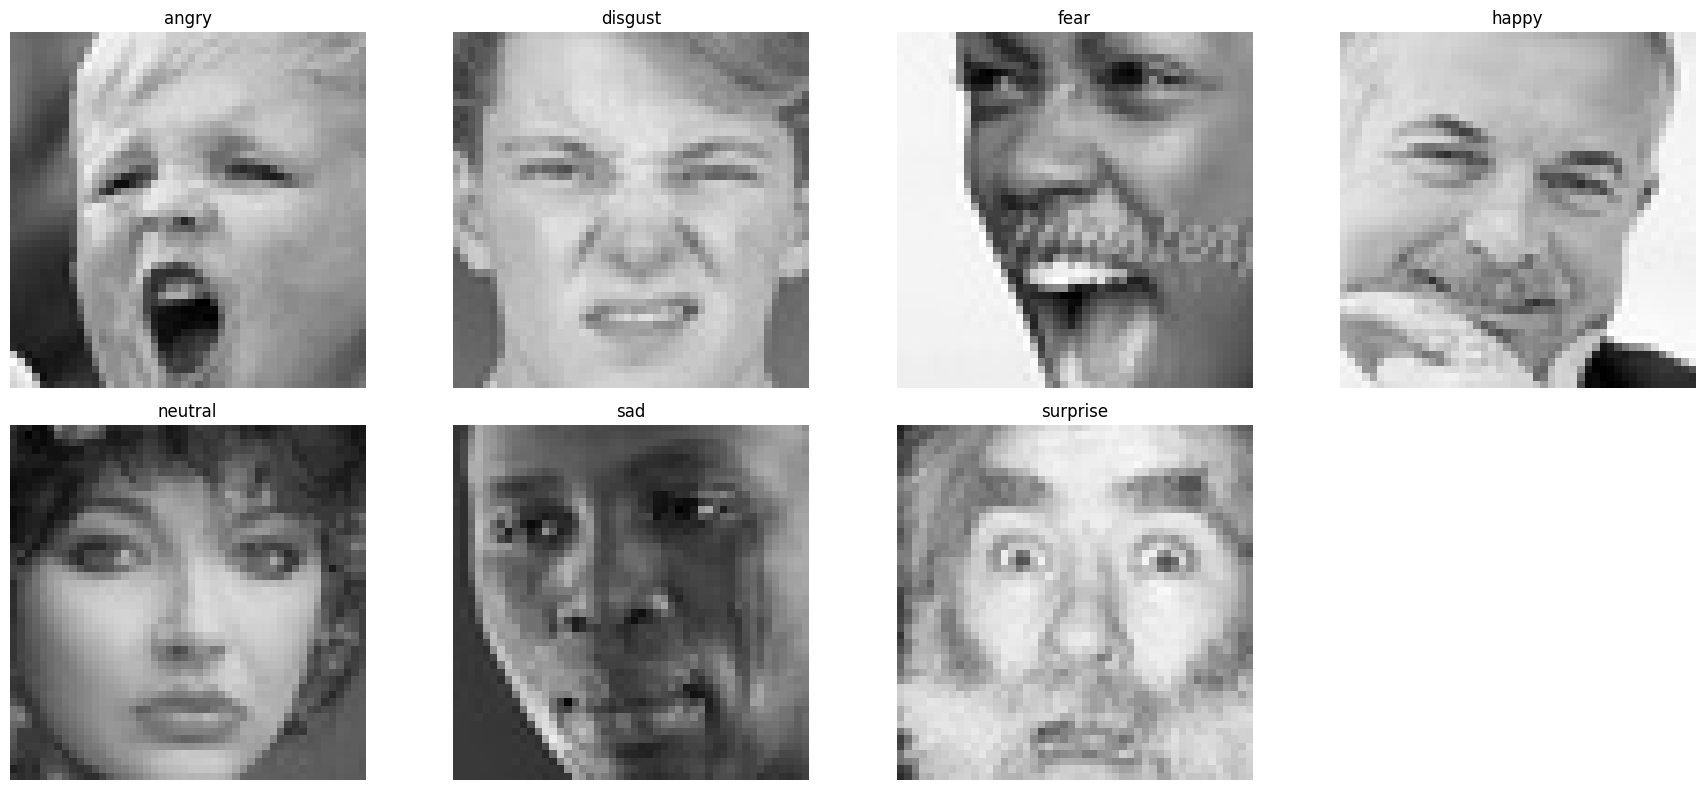

In [ ]:
import matplotlib.pyplot as plt
import cv2
import os
import random

# FER2013 base path
fer_input_path = "/content/archive/train" # Corrected path to include 'train' subdirectory

# Emotion classes
classes = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

# Display 1 image per class
plt.figure(figsize=(18, 8))

for i, cls_name in enumerate(classes):
    class_dir = os.path.join(fer_input_path, cls_name)
    image_files = os.listdir(class_dir)
    img_file = random.choice(image_files)  # Random image from class

    img_path = os.path.join(class_dir, img_file)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 4, i + 1)
    plt.imshow(img)
    plt.title(cls_name)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import cv2
import os

img = cv2.imread(
    '/content/archive/train/happy/' +
    os.listdir('/content/archive/train/happy')[0]
)

print(img.shape)

(48, 48, 3)


In [ ]:
import os

os.makedirs('/content/emotion_yolo/images/train', exist_ok=True)
os.makedirs('/content/emotion_yolo/images/val', exist_ok=True)

os.makedirs('/content/emotion_yolo/labels/train', exist_ok=True)
os.makedirs('/content/emotion_yolo/labels/val', exist_ok=True)

In [ ]:
emotion_map = {
    "angry": 0,
    "disgust": 1,
    "fear": 2,
    "happy": 3,
    "neutral": 4,
    "sad": 5,
    "surprise": 6
}

In [10]:
import shutil

train_path = "/content/archive/train"

for emotion in emotion_map:

    emotion_folder = os.path.join(train_path, emotion)

    for image_name in os.listdir(emotion_folder):

        src_image = os.path.join(
            emotion_folder,
            image_name
        )

        dst_image = os.path.join(
            "/content/emotion_yolo/images/train",
            f"{emotion}_{image_name}"
        )

        shutil.copy(src_image, dst_image)

        label_name = (
            f"{emotion}_{image_name}"
            .replace(".jpg", ".txt")
        )

        label_path = os.path.join(
            "/content/emotion_yolo/labels/train",
            label_name
        )

        with open(label_path, "w") as f:

            f.write(
                f"{emotion_map[emotion]} 0.5 0.5 1.0 1.0"
            )

In [11]:
test_path = "/content/archive/test"

for emotion in emotion_map:

    emotion_folder = os.path.join(
        test_path,
        emotion
    )

    for image_name in os.listdir(emotion_folder):

        src_image = os.path.join(
            emotion_folder,
            image_name
        )

        dst_image = os.path.join(
            "/content/emotion_yolo/images/val",
            f"{emotion}_{image_name}"
        )

        shutil.copy(src_image, dst_image)

        label_name = (
            f"{emotion}_{image_name}"
            .replace(".jpg", ".txt")
        )

        label_path = os.path.join(
            "/content/emotion_yolo/labels/val",
            label_name
        )

        with open(label_path, "w") as f:

            f.write(
                f"{emotion_map[emotion]} 0.5 0.5 1.0 1.0"
            )

In [12]:
len(os.listdir('/content/emotion_yolo/images/train'))

28709

In [13]:
%%writefile /content/emotion_yolo/data.yaml

path: /content/emotion_yolo

train: images/train
val: images/val

names:
  0: angry
  1: disgust
  2: fear
  3: happy
  4: neutral
  5: sad
  6: surprise

Writing /content/emotion_yolo/data.yaml


In [14]:
!cat /content/emotion_yolo/data.yaml


path: /content/emotion_yolo

train: images/train
val: images/val

names:
  0: angry
  1: disgust
  2: fear
  3: happy
  4: neutral
  5: sad
  6: surprise


In [15]:
!zip -r emotion_yolo.zip emotion_yolo

Streaming output truncated to the last 5000 lines.
  adding: emotion_yolo/images/val/happy_PrivateTest_35915421.jpg (stored 0%)
  adding: emotion_yolo/images/val/fear_PublicTest_4536412.jpg (stored 0%)
  adding: emotion_yolo/images/val/happy_PublicTest_7797976.jpg (stored 0%)
  adding: emotion_yolo/images/val/angry_PrivateTest_98403294.jpg (stored 0%)
  adding: emotion_yolo/images/val/happy_PrivateTest_19304106.jpg (stored 0%)
  adding: emotion_yolo/images/val/angry_PrivateTest_1809180.jpg (stored 0%)
  adding: emotion_yolo/images/val/happy_PublicTest_81626629.jpg (stored 0%)
  adding: emotion_yolo/images/val/fear_PublicTest_13590004.jpg (stored 0%)
  adding: emotion_yolo/images/val/happy_PublicTest_64717014.jpg (stored 0%)
  adding: emotion_yolo/images/val/surprise_PrivateTest_36889392.jpg (stored 0%)
  adding: emotion_yolo/images/val/neutral_PrivateTest_39987047.jpg (stored 0%)
  adding: emotion_yolo/images/val/happy_PublicTest_65949833.jpg (stored 0%)
  adding: emotion_yolo/images/v